In [26]:
import boto3
from langgraph.graph import START, StateGraph, END
from langchain_aws import ChatBedrock, BedrockEmbeddings
import json 
from IPython.display import Image, display
from langchain_chroma import Chroma
from langsmith import traceable, Client
from langchain_community.cache import SQLiteCache
from langchain_classic.retrievers.ensemble import EnsembleRetriever
from langchain_community.retrievers.bm25 import BM25Retriever
import os, ssl, certifi, requests
from langchain_core.globals import set_llm_cache
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate
from typing import TypedDict, List
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma



In [ ]:
# CONSTANTS

# Your LangSmith env vars
os.environ["LANGSMITH_TRACING_V2"] = "true"
os.environ["LANGSMITH_API_KEY"] = "lsv2_pt_xxxxxxxxxxxxxxx_cXXXXXXXXXXX"
os.environ["LANGSMITH_PROJECT"] = "test-navigator"
os.environ["LANGSMITH_CACHE"] = "sqlite:///langchain_cache.db"

# Your vectorstore defined path
LOCAL_VECTORSTORE_PATH = '/Users/sridhartondapi/Documents/python_self_corr_rag_prj_v1/.data/chroma_db'

# Your inference model id
MODEL_ID = "us.anthropic.claude-3-7-sonnet-20250219-v1:0" 

# Your AWS Boto3 connection details
bedrock = boto3.client(service_name="bedrock-runtime", region_name='us-east-1')

# Your memory cache details, 
# Prompt (your question + system prompt + retrieved context) LLM config (model, temperature, etc.)
# Same input → instant cache hit, skips LLM call.

set_llm_cache(SQLiteCache(database_path='/Users/sridhartondapi/Documents/python_self_corr_rag_prj_v1/retrieval/agents/memory/langchain_cache.db'))


In [28]:
import os
import ssl
import certifi

# Fix SSL for Python 3.13+ on macOS
os.environ['SSL_CERT_FILE'] = certifi.where()
ssl._create_default_https_context = ssl.create_default_context

print("Env vars set. Key valid?", "lsv2_pt_" in os.environ["LANGSMITH_API_KEY"])

try:
    response = requests.get("https://api.smith.langchain.com/info", timeout=10)
    print(f"SSL Test: SUCCESS (Status: {response.status_code})")
except Exception as e:
    print(f"SSL Test FAILED: {e}")

# Test LangSmith client
client = Client()
print("LangSmith Client: READY")


Env vars set. Key valid? True
SSL Test: SUCCESS (Status: 200)
LangSmith Client: READY


In [29]:
class NavigationResponse(BaseModel):
    question: str = Field()
    answer:str = Field()

In [30]:
PROMPT_TEMPLATE = """
=== RELEVANT DOCUMENTS — READ THESE FIRST (THIS IS THE ONLY EVIDENCE) ===
{context}

=== INSTRUCTIONS (follow strictly) ===
**Identify the document and filters to use based strictly on the provided context chunks above.**

**Instructions**
- For questions like "How to check [something]?", "How many [something] by [something]?", "How to find [entity_1] by [entity_2] and [entity_3] [value]", or "Show [something]":
- Extract all main entities explicitly mentioned or implied in the question (e.g., "students" and "event" from "How many students by event", "valid students registrations" as "#Validated Student Registrations"). Special case: If the question includes "NMSC details", extract both "NMSC Index" and "NMSC Eligibility Ind" as entities. These entities correspond to filter names or columns in the document.
- To map entities to document-specific columns:
- Check the synonym reference document 'Business attribute synonym reference.pdf' within the context chunks only if the entity matches a "Filter Synonyms" entry. The synonym reference includes columns: "Filter Name" (e.g., "Event Name") and "Filter Synonyms" (e.g., "event, event title, Examsubmsncomplete, Submission Success"). If a match is found, use the corresponding "Filter Name" (e.g., "rei" maps to "Roster Entry ID" if "Filter Name: Roster Entry ID, Filter Synonyms: rei, reid, Rosterentryid"; "catapult id" maps to "Catapult ID" if "Filter Name: Catapult ID, Filter Synonyms: catapult id"; "NMSC details" maps to both "NMSC Index" and "NMSC Eligibility Ind" if "Filter Name: NMSC Index, Filter Synonyms: NMSC details" and "Filter Name: NMSC Eligibility Ind, Filter Synonyms: NMSC details"; "Examsubmsncomplete", "Submission Success", or "submitted students" maps to "Student Test Status" if "Filter Name: Student Test Status, Filter Synonyms: Examsubmsncomplete, Submission Success, submitted students"; "Submission Success" or "submitted students" maps to "Test Admin Status" if "Filter Name: Test Admin Status, Filter Synonyms: Submission Success, submitted students"; "test center", "test center info", or "testing AI name" maps to "Test Center Name", "High School Name", or "TC Name" if "Filter Name: Test Center Name, Filter Synonyms: test center, test center info, Testing AI Name"; "testing AI code" maps to "AI Code" if "Filter Name: AI Code, Filter Synonyms: testing AI code"; "reg no", "Asmt Reg No", or "registration" maps to "Registration Number" if "Filter Name: Registration Number, Filter Synonyms: reg no, Asmt Reg No, registration"; "district id" maps to "District ID" if "Filter Name: District ID, Filter Synonyms: district id"; "Asmtdeliverymode" maps to "Delivery Mode" if "Filter Name: Delivery Mode, Filter Synonyms: Asmtdeliverymode"; "app check in admin status" maps to "Test Admin Status" if "Filter Name: Test Admin Status, Filter Synonyms: app check in admin status"; "force submitted" or "force submission" maps to "Force Submission" if "Filter Name: Force Submission, Filter Synonyms: force submitted, force submission"; "Scoring date", "score date", or "sent to scoring" maps to "Sent to Scoring Date" if "Filter Name: Sent to Scoring Date, Filter Synonyms: Scoring date, score date, sent to scoring"; "ir", "IRs", "incident reports", or "Irregularity" maps to "IRs" if "Filter Name: IRs, Filter Synonyms: ir, IRs, incident reports, Irregularity"; "IM Counts" or "IM count" maps to "Integrity Sync Response Counts" if "Filter Name: Integrity Sync Response Counts, Filter Synonyms: IM Counts, IM count"; "RM Counts" or "RM count" maps to "Results Sync Response Counts" if "Filter Name: Results Sync Response Counts, Filter Synonyms: RM Counts, RM count"; "test date", "started testing on", "tested on", or "testing on" maps to "Test Start Date" or "Actual Start Date" if "Filter Name: Test Start Date, Filter Synonyms: test date, started testing on, tested on, testing on" or "Filter Name: Actual Start Date, Filter Synonyms: test date, start date, started testing on, tested on, testing on"; "Scorestatus" maps to "Score Status" if "Filter Name: Score Status, Filter Synonyms: Scorestatus").
- If the entity does not match any "Filter Synonyms" in the 'Business attribute synonym reference.pdf', use the entity directly as the "Filter Name" (e.g., "Extended Time Flag", "NMSC Index", "NMSC Eligibility Ind", "Device Name", "State Accountability", "TDTK Readiness", "Roster Entry ID", "Confidence Index", "Catapult ID", "AI Code", "District ID").
- For each entity, check the document’s metadata within the context chunks, which includes columns: "Filter Name" (e.g., "Event Name"), "Filter Description", "Filter Examples" (e.g., "Y, N"), and "Is it a filter (Y/N)". Use the "Filter Name" (either mapped from the synonym reference or the entity itself) as the filter in the response. For synonym-mapped entities, the "Filter Name" must have "Is it a filter: Y" in the document’s metadata. For directly used entities, the "Filter Name" must be present in the document’s metadata, regardless of "Is it a filter" status. Select the document-specific "Filter Name" from the metadata (e.g., "Test Start Date" for SAT & PSAT Student Submission Report, "Actual Start Date" for SAT School Day & PSAT End to End Dashboard, "IRs" for SAT & PSAT Student Submission Report). If no match is found in the synonym reference or document metadata, proceed to fallback mappings.
- Validate or format values from the question using "Filter Examples" (e.g., "yes" maps to "Y"; dates like "1/1/2018" or "January 1, 2018" format as "2018-01-01" if "Filter Examples" uses ISO format; "Score Status" maps "cancelled" to "cancelled"; "Delivery Mode" maps "paperLinear" to "paperLinear"; IDs like "11254254-bf0f-40ae-8947-c5b4b66cddc4" for "Roster Entry ID", "P006437325" for "Registration Number", "491365" for "AI Code", or "100103" for "District ID" use as provided; "force submitted" or "force submission" maps to "Force Submission" with value "Y" if "Filter Examples" includes "Y"). For "Confidence Index", map values: "HIGH" to "HIGH_CONFIDENCE_PACKAGE"; "low unsubmitted confidence ratio" or "unsubmitted low" to "UNSUBMITTED_LOW"; "low package loss" to "VERIFIED_LOSS_PACKAGE_LOW"; "incomplete package" to "POSSIBLE_INCOMPLETE_PACKAGE"; "low confidence" to "UNSUBMITTED_LOW"; "medium confidence" to "UNSUBMITTED_MEDIUM"; "high confidence" to "HIGH_CONFIDENCE_PACKAGE"; "non-scoreable" to "NON_SCOREABLE_PACKAGE"; "non-attempted" to "NON_ATTEMPTED_PACKAGE"; "complete package" to "POSSIBLE_COMPLETE_PACKAGE"; "high package loss" to "VERIFIED_LOSS_PACKAGE_HIGH". If multiple values are specified (e.g., "VERIFIED_LOSS_PACKAGE_LOW or POSSIBLE_INCOMPLETE_PACKAGE"), include all using "or". If no value is provided but the entity implies a filter (e.g., "valid students registrations"), use the "Filter Name" without assuming a value. For "submitted students" or "Submission Success", map to "Student Test Status" with "Submitted" for SAT & PSAT Student Submission Report or "Test Admin Status" with "Answer Submission Success" for SAT School Day & PSAT Test Day Report if no other value is specified. For "unsubmitted students", "didn't submit", or "not submitted", map to "Student Test Status" with "Not Submitted" for SAT & PSAT Student Submission Report or "Test Admin Status" with "Did not submit answers successfully" for SAT School Day & PSAT Test Day Report. For "tdtk", map "high tdtk" to "TDTK Readiness" with "High Risk" and "low tdtk" to "TDTK Readiness" with "Low Risk" if "TDTK Readiness" is in the context, unless otherwise specified. If a specific value is provided for an entity (e.g., an ID for "Roster Entry ID", "Registration Number", "AI Code", or "District ID"), include the value in the response across all relevant documents.
- As a fallback, use predefined mappings only when no match exists in the 'Business attribute synonym reference.pdf' or document metadata (e.g., "confidence" or "confidence index" to "Confidence Index"; "event" or "event title" to "Event Name"; "Roster Entry ID", "rei", "reid", or "Rosterentryid" to "Roster Entry ID"; "students submitted", "submitted students", or "Submission Success" to "Student Test Status" with "Submitted" for SAT & PSAT Student Submission Report or "Test Admin Status" with "Answer Submission Success" for SAT School Day & PSAT Test Day Report; "unsubmitted students", "did not submit answers", or "not submitted" to "Student Test Status" with "Not Submitted" for SAT & PSAT Student Submission Report or "Test Admin Status" with "Did not submit answers successfully" for SAT School Day & PSAT Test Day Report; "valid students registrations" to "#Validated Student Registrations"; "tdtk" to "TDTK Readiness"; "Hold" to "active hold" or "Hold"; "scoring date" or "score date" to "Sent to Scoring Date"; "test date", "students tested on [date]", "started testing on", or "testing on" to "Test Start Date" for SAT & PSAT Student Submission Report or "Actual Start Date" for SAT School Day & PSAT End to End Dashboard, PSAT TDTK Readiness, or SAT School Day & PSAT Exam schedule Report; "test center", "test center info", or "testing AI name" to "Test Center Name", "High School Name", or "TC Name"; "testing AI code" to "AI Code"; "exam completed" to "exam setup completed"; "multiday" to "Multiday" or "Multi-Day"; "delaware state" or "state" to "State" with value "Delaware"; "force submitted" or "force submission" to "Force Submission" with value "Y"; "ir", "IRs", "incident reports", or "Irregularity" to "IRs"; "IM Counts" or "IM count" to "Integrity Sync Response Counts"; "RM Counts" or "RM count" to "Results Sync Response Counts"; "registration" to "Registration Number"; "district id" to "District ID"; "Scorestatus" to "Score Status"). Always prefer mappings from the 'Business attribute synonym reference.pdf' or direct metadata matches over fallbacks.
- Examine each chunk in the context, tagged as "text (from filename.pdf)".
- For single-entity questions (e.g., "test date" or "device information"), identify every document where the entity (or its mapped "Filter Name" from the 'Business attribute synonym reference.pdf' or directly from the entity) is present in the document’s metadata. For synonym-mapped entities, require "Is it a filter: Y". For directly checked entities (e.g., "Device Name", "Roster Entry ID", "NMSC Index", "NMSC Eligibility Ind", "Confidence Index", "Catapult ID", "AI Code", "District ID"), require only presence in metadata. For date-based queries (e.g., "test date", "students tested on [date]", "started testing on", "testing on"), include all documents with date-related filters: "Test Start Date" in SAT & PSAT Student Submission Report, "Actual Start Date" in SAT School Day & PSAT End to End Dashboard, PSAT TDTK Readiness, and SAT School Day & PSAT Exam schedule Report. List all such documents with their context-specific "Filter Name" in the response using a numbered list format.
- For multi-entity questions (e.g., "test center info", "reg no", "State", "unsubmitted students", "Rosterentryid", "Asmtdeliverymode"), identify all documents where every entity (or their mapped "Filter Name" from the 'Business attribute synonym reference.pdf' or directly from the entity) has a corresponding metadata entry in the same document’s metadata with "Is it a filter: Y" for synonym-mapped entities and mere presence for directly checked entities. Include only documents where all entities are present in the metadata. List all such documents in a numbered list format, ensuring documents like "SAT & PSAT Student Submission Report" and "SAT School Day & PSAT Test Day Report" are included when "Student Test Status" or "Test Admin Status" (mapped from "unsubmitted students", "didn't submit", or "not submitted") are involved alongside other entities like "State" or "Roster Entry ID". If no document contains all entities, return "No relevant document found for [entities]. source(none)", except for queries involving "Score Status", where check SAT & PSAT Student Submission Report specifically and validate that all entities are present with "Is it a filter: Y". For date-based queries (e.g., "started testing on MM/DD/YYYY"), include all documents with date-related filters (e.g., "Test Start Date" in SAT & PSAT Student Submission Report, "Actual Start Date" in SAT School Day & PSAT End to End Dashboard, PSAT TDTK Readiness, SAT School Day & PSAT Exam schedule Report) and use the parsed date (e.g., "YYYY-MM-DD"), ensuring all other entities are present in the document’s metadata. Prioritize "SAT & PSAT Student Submission Report" for queries involving "Score Status", "Confidence Index", "AI Code", "IM Counts", "RM Counts", "District ID", or "Sent to Scoring Date", and "SAT School Day & PSAT Test Day Report" for queries involving "Test Admin Status" or "NMSC details".
- Check all chunks across the entire context. For multi-entity questions, if any entity lacks a metadata entry in a document or entities are split across chunks from different documents without a single document containing metadata entries for all, return "No relevant document found for [entities]. source(none)", unless the query includes "Score Status". For single-entity questions, return all documents with the entity or its synonym present (with appropriate "Is it a filter" validation).
- If the question implies filtering (e.g., "by [entity]"), treat all extracted entities as filters to be applied in the identified documents. Use the "Filter Name" from the document’s metadata for each filter in the response (e.g., "Event Name" for SAT & PSAT Student Submission Report if "event title" maps to it). If no match is found in the 'Business attribute synonym reference.pdf' or document metadata, use the fallback mapping or the question’s term if no conflict exists. If multiple documents use different "Filter Names" for the same entity (e.g., "Actual Start Date" in one, "Test Start Date" in another), reflect the document-specific "Filter Name" in the response for each document. If a specific value is provided for an entity (e.g., an ID for "Roster Entry ID", "Registration Number", "AI Code", or "District ID"), include the value in the response for that entity across all relevant documents.
- Special case for response formatting:
- For queries involving "Score Status", "Roster Entry ID", "Test Start Date", "Catapult ID", "NMSC details", "Examsubmsncomplete", "Submission Success", "submitted students", "unsubmitted students", "test center info", "Testing AI Name", "testing AI code", "reg no", "Asmt Reg No", "force submitted", "Scoring date", "IRs", "IM Counts", "RM Counts", "District ID", or date-based queries, generalize document names in navigation instructions:
- "SAT & PSAT Student Submission Report" to "Student Submission Report of your specific year"
- "SAT School Day & PSAT Test Day Report" to "Test Day report of your specific year"
- "SAT School Day & PSAT End to End Dashboard" to "End to End Dashboard of your specific year"
- "PSAT TDTK Readiness" to "TDTK Readiness report of your specific year"
- "SAT School Day & PSAT Exam schedule Report" to "Exam schedule report of your specific year"
- Keep the original document name in the source reference (e.g., "source(SAT & PSAT Student Submission Report_final_syno.pdf)"). Use "SAT & PSAT Student Submission Report_final_wo_syn.pdf" for queries explicitly involving "Score Status", "Confidence Index", "AI Code", "District ID", or "Sent to Scoring Date" unless metadata specifies otherwise; use "SAT & PSAT Student Submission Report_final_syno.pdf" for other synonym-mapped filters (e.g., "IM Counts", "RM Counts") unless metadata indicates a different file. Use "SAT School Day & PSAT Test Day Report_final.pdf" for queries involving "Test Admin Status" or "NMSC details". Use "SAT School Day & PSAT End to End Dashboard_final.pdf" for "End to End Dashboard" and "PSAT TDTK Readiness_final.pdf" for "TDTK Readiness report" and "SAT School Day & PSAT Exam schedule Report_final.pdf" for "Exam schedule report".
- Response format:
- If all entities are found in one document and include a value: "please navigate to the [file_name] and select [entity_1] as '[value]' and [entity_2] filter source([file_name].pdf)"
- If all entities are found in one document without a value: "please navigate to the [file_name] and filter [entity_1] and [entity_2] accordingly source([file_name].pdf)"
- If multiple documents each contain all entities (or the single entity for single-entity questions): "1. please navigate to [file_name] and select [entity_1] as '[value]' filter source([file_name].pdf)\n2. please navigate to [file_name] and select [entity_1] as '[value]' filter source([file_name].pdf)"
- If no single document contains all entities (for multi-entity questions, unless involving "Score Status"): "No relevant document found for [entities]. source(none)"
- Remove the '.pdf' extension from file names in navigation instructions, but include it in source references (e.g., "source([file_name].pdf)").
- Strictly output only the specified response format without any explanatory text, additional details, or extra source documents beyond those referenced in the navigation instructions. Do not include phrases like "Based on the context provided" or any analysis outside the formatted response.
- For questions like "What is [something]?" or "explain what is [something]":
- Extract the entity (e.g., "confidence index" from "What is confidence index?") and provide a concise description based on the context from all relevant documents where it or its synonyms (from the 'Business attribute synonym reference.pdf' if applicable or content) are mentioned, using "Filter Description" if available.
- Response format: "[Entity] is [description based on context or Filter Description] source([file_name].pdf)" for one document, or "[Entity] is [description based on context or Filter Description] sources([file_name1].pdf, [file_name2].pdf)" for multiple.
- Ensure the response is concise, matches the example format exactly, and avoids hallucination. Use the 'Business attribute synonym reference.pdf' for synonym mappings and direct metadata matches for filter selection, falling back to predefined mappings only when necessary.

**Examples**
- Question: "how to check for device information" Answer: "please navigate to the Test Day report of your specific year and filter Device Name accordingly source(SAT School Day & PSAT Test Day Report_final.pdf)"
- Question: "How to check for scoring date for a test center and district id as 100103" Answer: "please navigate to the Student Submission Report of your specific year and filter Sent to Scoring Date and Test Center Name and District ID as '100103' accordingly source(SAT & PSAT Student Submission Report_final_wo_syn.pdf)"
- Question: "how to check for students tested on 10/8/2024" Answer: "1. please navigate to the Student Submission Report of your specific year and filter Test Start Date as '2024-10-08' accordingly source(SAT & PSAT Student Submission Report_final_wo_syn.pdf)\n2. please navigate to the Test Day report of your specific year and filter Test Start Date as '2024-10-08' accordingly source(SAT School Day & PSAT Test Day Report_final.pdf)\n3. please navigate to the End to End Dashboard of your specific year and filter Actual Start Date as '2024-10-08' accordingly source(SAT School Day & PSAT End to End Dashboard_final.pdf)\n4. please navigate to the TDTK Readiness report of your specific year and filter Actual Start Date as '2024-10-08' accordingly source(PSAT TDTK Readiness_final.pdf)\n5. please navigate to the Exam schedule report of your specific year and filter Actual Start Date as '2024-10-08' accordingly source(SAT School Day & PSAT Exam schedule Report_final.pdf)"
- Question: "how to check for low tdtk by Event Name as 'PSAT 8/9 Fall 2024 primary'" Answer: "1. please navigate to the End to End Dashboard of your specific year and select Event Name as 'PSAT 8/9 Fall 2024 primary' and TDTK Readiness as 'Low Risk' filter source(SAT School Day & PSAT End to End Dashboard_final.pdf)\n2. please navigate to the TDTK Readiness report of your specific year and select Event Name as 'PSAT 8/9 Fall 2024 primary' and TDTK Readiness as 'Low Risk' filter source(PSAT TDTK Readiness_final.pdf)"
- Question: "What is confidence index?" Answer: "Confidence Index is a measure of the reliability of student test submissions, indicating the likelihood of complete and accurate data based on test conditions and submission status source(SAT & PSAT Student Submission Report_final_wo_syn.pdf)"

Question: {question}
Answer:
"""

In [31]:
custom_prompt = PromptTemplate(
    input_variables = ["question","answer"],
    template = PROMPT_TEMPLATE
)

In [32]:
def bedrock_connection():
    try:
        return ChatBedrock(
            client = bedrock,
            model_id = MODEL_ID,
            model_kwargs = {
                "temperature": 0.2,
                "top_p": 0.2,
                "max_tokens": 1024
            }
        )
    except Exception as e:
        print (f"Unable to connect to the Bedrock Model: {str(e)}")

In [33]:
llm = bedrock_connection()

In [34]:
class AgentState(TypedDict):
    question: str
    answer: str
    iteration: str
    retrieved_documents: List[Document]
    retrieved_sources: List[Document]
    bm25_retriever: BM25Retriever

In [35]:
class RetrievalContext:
    def __init__(self, vectorstore, bm25):
        self.vectorstore = vectorstore
        self.bm25 = bm25

    def hybrid_retrieve(self, query: str, k: int = 50,semantic_weight:float = 0.75):
        semantic = self.vectorstore.as_retriever(
            search_type = "mmr",
            search_kwargs = {"k":k,"fetch_k": 80,"lambda_mult":0.4}
        )

        hybrid = EnsembleRetriever(
            retrievers = [semantic, self.bm25],
            weights = [semantic_weight, 1-semantic_weight]
        )

        return hybrid.invoke(query)

In [36]:
embeddings = BedrockEmbeddings(
    client = bedrock,
    model_id = "amazon.titan-embed-text-v2:0"
)

collection_name = "pdf_knowledge_base"

vectorstore = Chroma(
    persist_directory = LOCAL_VECTORSTORE_PATH,
    embedding_function=embeddings,
    collection_name=collection_name
)

data = vectorstore.get()

if not data.get('documents'):
    print ("No documents foind in the vectorstore.")
else:
    texts = data['documents']
    metadatas = data['metadatas']
    
    bm25_retriever = BM25Retriever.from_texts(
        texts = texts,
        metadatas=metadatas,
        bm25_params=None
    )
    
    bm25_retriever.k = 50
    
    retrieval_ctx = RetrievalContext(vectorstore, bm25_retriever)


In [37]:
def bedrock_cohere_rerank(query: str, docs:list, top_n:int=50):
    doc_texts = [doc.page_content for doc in docs]

    payload = {
        "query": query,
        "documents": doc_texts,
        "top_n": top_n,
        "api_version":2
    }

    response = bedrock.invoke_model(
        modelId = "cohere.rerank-v3-5:0",
        contentType ="application/json",
        accept = "application/json",
        body = json.dumps(payload).encode("utf-8")
    )

    result = json.loads(response['body'].read().decode("utf-8"))

    reranked_docs = [docs[item["index"]] for item in result['results']]

    return reranked_docs

In [38]:
@traceable
def retrieve_documents(state:AgentState) -> AgentState:
    query = state['question']
    hybrid_docs = retrieval_ctx.hybrid_retrieve(query)

    print (f"DBUG: The hybrid docs from the ensemble retriever are: {hybrid_docs}")

    reranked_docs = bedrock_cohere_rerank(
        query = query,
        docs = hybrid_docs
    )

    state['retrieved_documents'] = reranked_docs

    state['retrieved_sources'] = [doc.metadata.get("sources","unknown") for doc in reranked_docs]

    return {**state}


In [39]:
@traceable
def generate_answer(state:AgentState) -> AgentState:
    question = state['question']
    retrieved_documents = state['retrieved_documents']

    try:
        initial_answer = custom_prompt.format(
            question = question,
            context = retrieved_documents
        )

        initial_response = llm.invoke(initial_answer).content.strip()

        structured = NavigationResponse(
            question = question,
            answer = initial_reponse
        )

        state['answer'] = structured.model_dump_json(indent=2)
    except Exception as e:
        fallback = NavigationResponse(
            question = question,
            answer = initial_response or "Unable to generate any accurate steps."
        )

        state['answer'] = fallback.model_dump_json(indent=2)
    return {**state}

In [40]:
@traceable
def self_correct(state:AgentState) -> AgentState:
    answer = state['answer']
    question = state['question']
    retrieved_documents = state['retrieved_documents']

    try:
        correction_prompt = """You are reviewing an Ai's answer.Review the answer and decide if it is accurate based on the provided context. If its fully correct, \
        respond only with "ACCEPT". If it's wrong or incomplete, provide a corrected or improved version.
        Question: {question}
        Answer: {answer}
        Context: {docs}
        """

        correction_input = correction_prompt.format(
            question = question,
            answer = answer,
            docs = retrieved_documents
        )

        correction_output = llm.invoke(correction_input).content.strip()
        if correction_output == "ACCEPT":
            return {**state, "iteration": state.get('iteration',0)+1, "answer": answer}
        return {**state, "iteration":state.get('iteration', 0 )+ 1,"answer": correction_output}
    except Exception as e:
        print (f"Error in the self-correction: {str(e)}")
        return {**state}

In [ ]:
def should_continue(state:AgentState) -> str:
    if state.get('iteration', 0) >=2:
        return END
    return "self_correct"

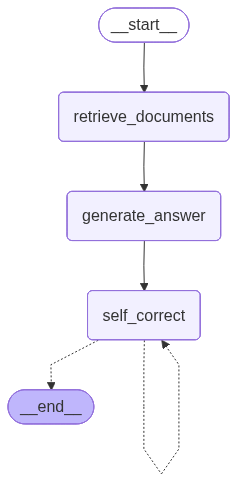

In [42]:
workflow = StateGraph(AgentState)

workflow.add_node("retrieve_documents", retrieve_documents)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("self_correct", self_correct)

workflow.add_edge(START, "retrieve_documents")
workflow.add_edge("retrieve_documents","generate_answer")
workflow.add_edge("generate_answer","self_correct")
workflow.add_conditional_edges("self_correct",should_continue,
{
    END:END,
    "self_correct":"self_correct"
})

app = workflow.compile()

display(Image(app.get_graph().draw_mermaid_png()))


In [44]:
result = app.invoke({
    "question":"show me the students from delaware that started the test but didnt submit and REID",
    "answer":"",
    "retrieved_documents": [],
    "retrieved_docs":[],
    "iteration": 0,
    "bm25_retriever": bm25_retriever

})

print ((result['answer']))
print(f"iteration:{result['iteration']}")

DBUG: The hybrid docs from the ensemble retriever are: [Document(metadata={'filename': 'SAT & PSAT Student Submission Report_final_wo_syn.pdf', 'page': 0, 'filter_names': '', 'report_type': 'SAT & PSAT Student Submission Report_final_wo_syn', 'source': 'SAT & PSAT Student Submission Report_final_wo_syn.pdf', 'chunk_id': 'SAT & PSAT Student Submission Report_final_wo_syn.pdf_p1_c1'}, page_content='1. When filtering for students who submitted exams, all students who attempted to submit are including. If their submission failed, they show as failed in the table. Working on changeto only show students who successfully submitted when filtering for submitted.2'), Document(metadata={'chunk_id': 'SAT & PSAT Student Submission Report_final_wo_syn.pdf_p1_c2', 'filename': 'SAT & PSAT Student Submission Report_final_wo_syn.pdf', 'report_type': 'SAT & PSAT Student Submission Report_final_wo_syn', 'page': 0, 'source': 'SAT & PSAT Student Submission Report_final_wo_syn.pdf', 'filter_names': ''}, page